In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful")

All imports successful


In [3]:
df = pd.read_csv('../data/processed/ipo_clean.csv', parse_dates=['listing_date'])

print(f"Shape: {df.shape}")
print(f"\nDate range: {df['listing_date'].min().date()} to {df['listing_date'].max().date()}")
print(f"\nListing gain stats:")
print(df['listing_gain_pct'].describe())

Shape: (297, 11)

Date range: 2016-01-06 to 2026-05-08

Listing gain stats:
count    277.000000
mean      22.991986
std       34.263313
min      -31.350000
25%        0.490000
50%       13.810000
75%       37.000000
max      195.530000
Name: listing_gain_pct, dtype: float64


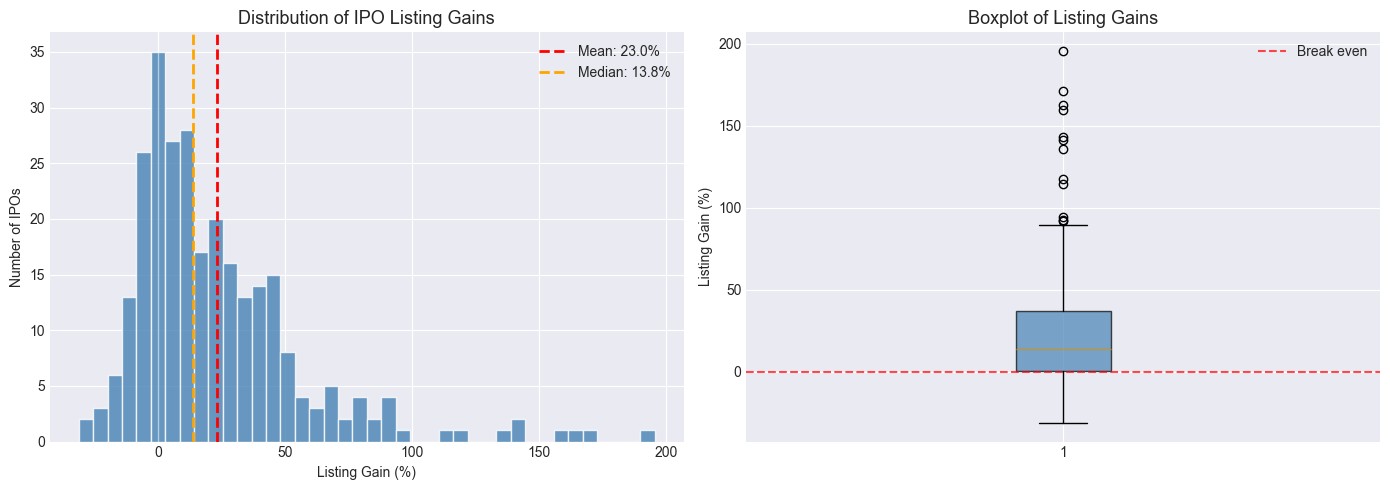

Saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
axes[0].hist(df['listing_gain_pct'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['listing_gain_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['listing_gain_pct'].mean():.1f}%")
axes[0].axvline(df['listing_gain_pct'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['listing_gain_pct'].median():.1f}%")
axes[0].axvline(0, color='white', linestyle='-', linewidth=1, alpha=0.5)
axes[0].set_title('Distribution of IPO Listing Gains', fontsize=13)
axes[0].set_xlabel('Listing Gain (%)')
axes[0].set_ylabel('Number of IPOs')
axes[0].legend()

# Right: boxplot
axes[1].boxplot(df['listing_gain_pct'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7, label='Break even')
axes[1].set_title('Boxplot of Listing Gains', fontsize=13)
axes[1].set_ylabel('Listing Gain (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/plot_gain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

   year  mean_gain  median_gain  ipo_count
0  2016  14.277778       14.900         27
1  2017  23.171053        3.250         38
2  2018  21.553333       11.090         12
3  2022  10.346154        5.800         39
4  2023  33.953922       22.180         51
5  2024  30.124000       20.955         90
6  2026  -0.108500       -2.400         20


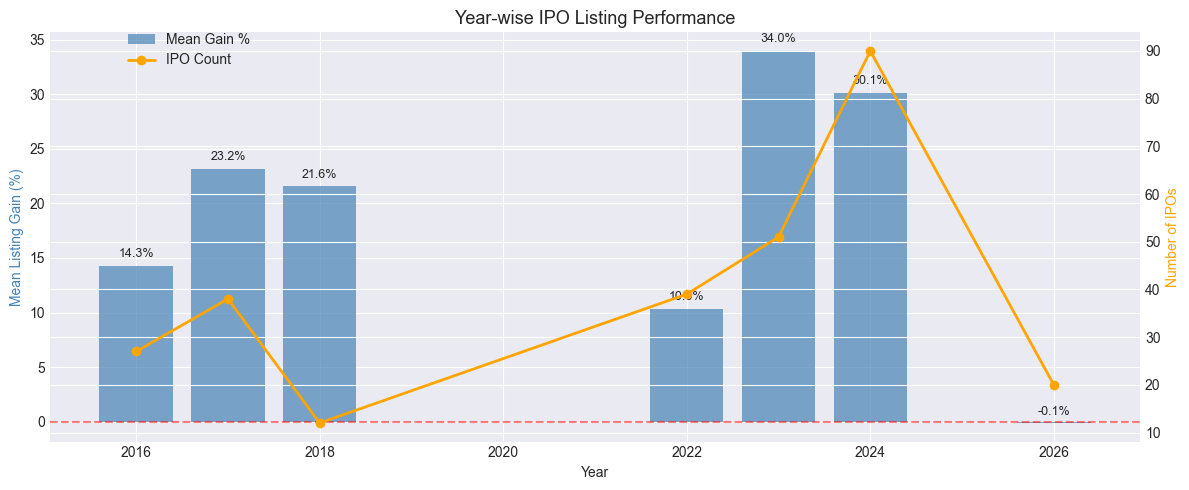

In [5]:
yearly = df.groupby('listing_year')['listing_gain_pct'].agg(['mean', 'median', 'count']).reset_index()
yearly.columns = ['year', 'mean_gain', 'median_gain', 'ipo_count']
print(yearly)

fig, ax1 = plt.subplots(figsize=(12, 5))

bars = ax1.bar(yearly['year'], yearly['mean_gain'], color='steelblue', alpha=0.7, label='Mean Gain %')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Listing Gain (%)', color='steelblue')
ax1.set_title('Year-wise IPO Listing Performance', fontsize=13)

# Overlay IPO count as line
ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['ipo_count'], color='orange', marker='o', linewidth=2, label='IPO Count')
ax2.set_ylabel('Number of IPOs', color='orange')

# Add value labels on bars
for bar, val in zip(bars, yearly['mean_gain']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('../data/processed/plot_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

    month  mean_gain  ipo_count month_name
0       1  22.394286         14        Jan
1       2  24.030526         19        Feb
2       3   6.644167         24        Mar
3       4  18.488235         17        Apr
4       5  11.632609         23        May
5       6  28.317500         12        Jun
6       7  40.570000         19        Jul
7       8  28.535652         23        Aug
8       9  26.734412         34        Sep
9      10  22.285714         21        Oct
10     11  17.454706         34        Nov
11     12  30.269730         37        Dec


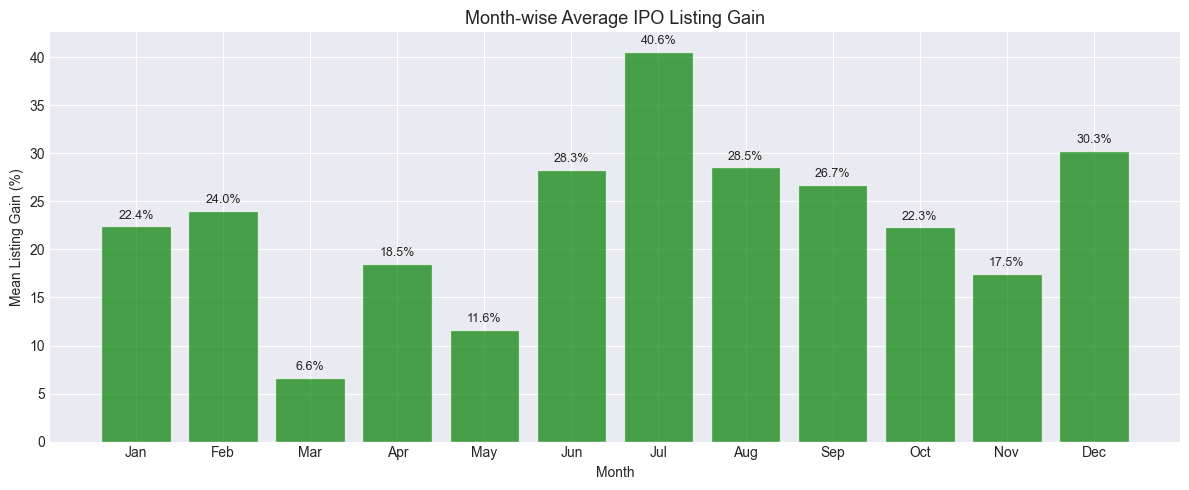

In [6]:
monthly = df.groupby('listing_month')['listing_gain_pct'].agg(['mean', 'count']).reset_index()
monthly.columns = ['month', 'mean_gain', 'ipo_count']

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly['month_name'] = monthly['month'].map(month_names)

print(monthly)

plt.figure(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in monthly['mean_gain']]
bars = plt.bar(monthly['month_name'], monthly['mean_gain'], color=colors, alpha=0.7, edgecolor='white')
plt.axhline(0, color='white', linestyle='-', linewidth=0.8, alpha=0.5)
plt.title('Month-wise Average IPO Listing Gain', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Mean Listing Gain (%)')

for bar, val in zip(bars, monthly['mean_gain']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/plot_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

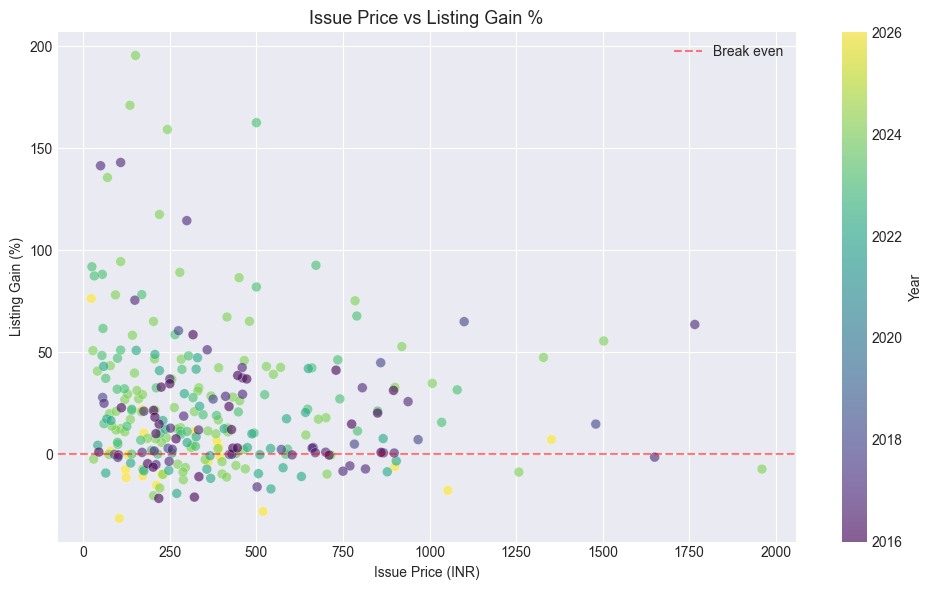

Correlation between issue price and listing gain: -0.1051


In [7]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df['issue_price'],
    df['listing_gain_pct'],
    c=df['listing_year'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.3,
    s=50
)

plt.colorbar(scatter, label='Year')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break even')
plt.title('Issue Price vs Listing Gain %', fontsize=13)
plt.xlabel('Issue Price (INR)')
plt.ylabel('Listing Gain (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_price_vs_gain.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = df['issue_price'].corr(df['listing_gain_pct'])
print(f"Correlation between issue price and listing gain: {corr:.4f}")

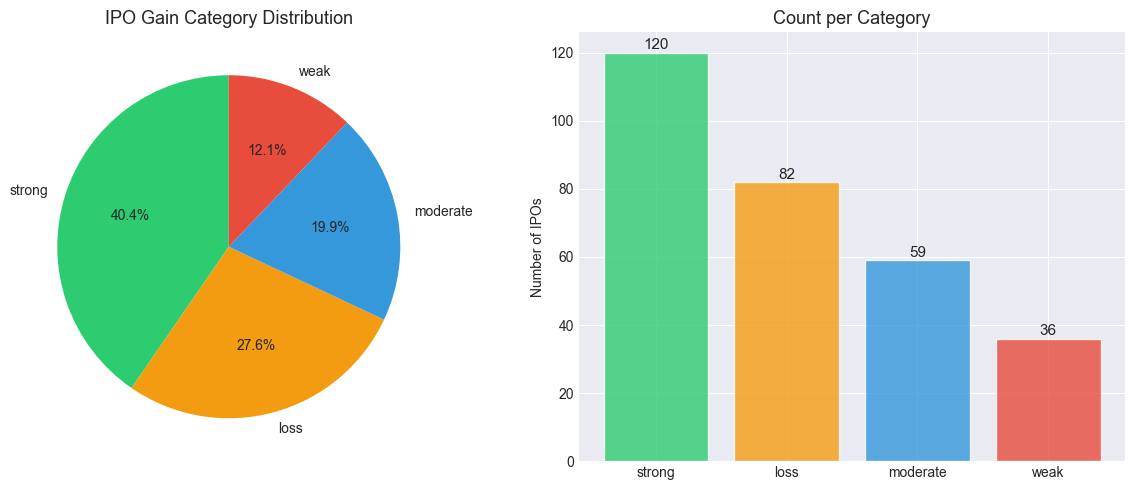

In [8]:
category_counts = df['gain_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors_pie = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']
axes[0].pie(category_counts.values, labels=category_counts.index,
            autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0].set_title('IPO Gain Category Distribution', fontsize=13)

# Bar chart with counts
axes[1].bar(category_counts.index, category_counts.values,
            color=colors_pie, edgecolor='white', alpha=0.8)
axes[1].set_title('Count per Category', fontsize=13)
axes[1].set_ylabel('Number of IPOs')
for i, (cat, val) in enumerate(category_counts.items()):
    axes[1].text(i, val + 1, str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/plot_categories.png', dpi=150, bbox_inches='tight')
plt.show()

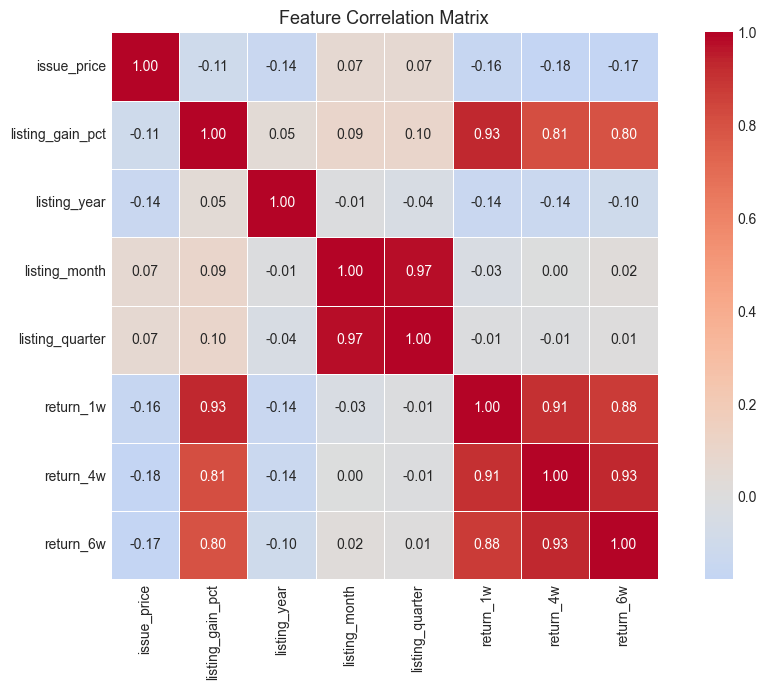

In [9]:
# Correlation heatmap of all numeric features
numeric_cols = ['issue_price', 'listing_gain_pct', 'listing_year',
                'listing_month', 'listing_quarter', 'return_1w', 'return_4w', 'return_6w']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()